
# Bayesian Regression and Gaussian Process Regression on the LIDAR dataset

**Data:** `lidar.csv` (221 obs of `range` and `logratio`, Ruppert et al. 2003)

## Setup

In [ ]:
# Install PyMC (not on Colab by default)
!pip install -q pymc arviz

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, WhiteKernel, ConstantKernel as C,
)
from sklearn.metrics import mean_squared_error

import pymc as pm
import arviz as az

# Reproducibility
RNG_SEED = 2025
np.random.seed(RNG_SEED)

# Plot defaults
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## Load the LIDAR dataset

Upload `lidar.csv` to Colab via the folder icon on the left sidebar before running the next cell.

In [ ]:
# Load data
lidar = pd.read_csv("lidar.csv")
print(f"Loaded LIDAR data: {len(lidar)} rows, {lidar.shape[1]} columns")
lidar.head()

Loaded LIDAR data: 221 rows, 2 columns


,range,logratio
0,390,-0.050356
1,391,-0.060097
2,393,-0.041901
3,394,-0.050985
4,396,-0.059913


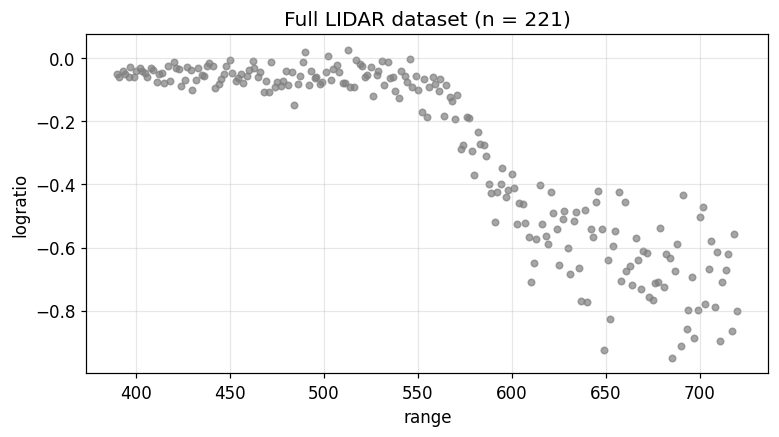

In [ ]:
# Quick look at the full dataset
plt.figure(figsize=(8, 4))
plt.scatter(lidar["range"], lidar["logratio"], s=18, c="grey", alpha=0.7)
plt.xlabel("range")
plt.ylabel("logratio")
plt.title("Full LIDAR dataset (n = 221)")
plt.show()

## Part 1 — Bayesian Linear Regression on a 100-point sample

Fit $\text{logratio} = \beta_0 + \beta_1 \cdot \text{range} + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, using PyMC (NUTS sampler).

Priors: $\beta_0, \beta_1 \sim \mathcal{N}(0, 10^2)$ and $\sigma \sim \text{HalfNormal}(1)$.

In [ ]:
# Q1: random subsample of 100 observations
np.random.seed(RNG_SEED)
sub_idx = np.random.choice(len(lidar), size=100, replace=False)
lidar_sub = lidar.iloc[sub_idx].reset_index(drop=True)

x_sub = lidar_sub["range"].values.astype(float)
y_sub = lidar_sub["logratio"].values.astype(float)

print(f"Subsample: {len(lidar_sub)} points")
print(f"  range:    {x_sub.min():.0f} to {x_sub.max():.0f}")
print(f"  logratio: {y_sub.min():.3f} to {y_sub.max():.3f}")

Subsample: 100 points
  range:    390 to 715
  logratio: -0.911 to -0.004


In [ ]:
# Q1: Bayesian linear regression with PyMC
with pm.Model() as bayes_model:
    # priors
    beta0 = pm.Normal("beta0", mu=0, sigma=10)
    beta1 = pm.Normal("beta1", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # likelihood
    mu = beta0 + beta1 * x_sub
    pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_sub)

    # draw posterior samples
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        random_seed=RNG_SEED,
        progressbar=True,
        return_inferencedata=True,
    )

print(az.summary(trace, var_names=["beta0", "beta1", "sigma"]))

Output()

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta0  1.127  0.080   0.980    1.276      0.002    0.001    2362.0    2955.0   
beta1 -0.003  0.000  -0.003   -0.002      0.000    0.000    2401.0    2953.0   
sigma  0.129  0.009   0.112    0.146      0.000    0.000    3618.0    3258.0   

       r_hat  
beta0    1.0  
beta1    1.0  
sigma    1.0  


### Q1 — Plot 1: scatter, posterior-mean fit, 95% credible band

Posterior means:
  beta0 = 1.1269
  beta1 = -0.002553
  sigma = 0.1294


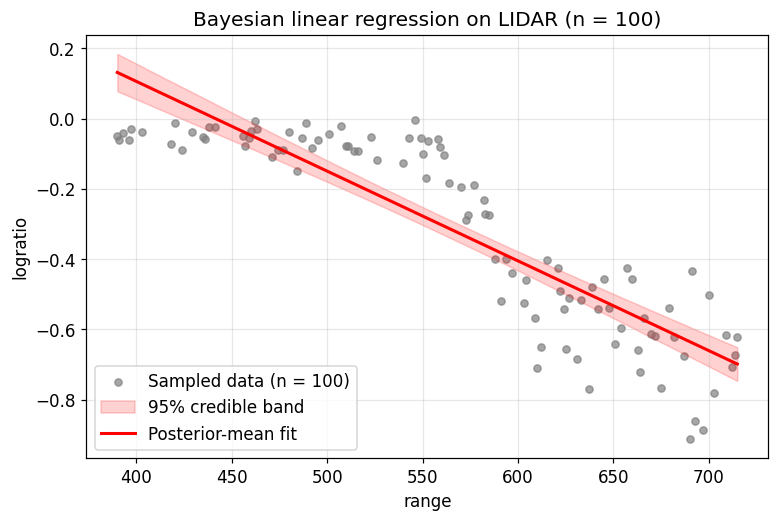

In [ ]:
# Q1: extract posterior samples
post = trace.posterior
beta0_samples = post["beta0"].values.flatten()
beta1_samples = post["beta1"].values.flatten()
sigma_samples = post["sigma"].values.flatten()

beta0_hat = beta0_samples.mean()
beta1_hat = beta1_samples.mean()
sigma_hat = sigma_samples.mean()

print(f"Posterior means:")
print(f"  beta0 = {beta0_hat:.4f}")
print(f"  beta1 = {beta1_hat:.6f}")
print(f"  sigma = {sigma_hat:.4f}")

# build credible band from MCMC draws
x_grid = np.linspace(x_sub.min(), x_sub.max(), 200)
post_lines = beta0_samples[:, None] + beta1_samples[:, None] * x_grid[None, :]
ci_lo = np.percentile(post_lines, 2.5,  axis=0)
ci_hi = np.percentile(post_lines, 97.5, axis=0)

plt.figure(figsize=(8, 5))
plt.scatter(x_sub, y_sub, s=22, c="grey", alpha=0.7, label="Sampled data (n = 100)")
plt.fill_between(x_grid, ci_lo, ci_hi, color="red", alpha=0.18, label="95% credible band")
plt.plot(x_grid, beta0_hat + beta1_hat * x_grid, color="red", lw=2, label="Posterior-mean fit")
plt.xlabel("range")
plt.ylabel("logratio")
plt.title("Bayesian linear regression on LIDAR (n = 100)")
plt.legend(loc="lower left")
plt.show()

### Q1 — Plot 2: posterior histograms of $\beta_0$, $\beta_1$, $\sigma^2$

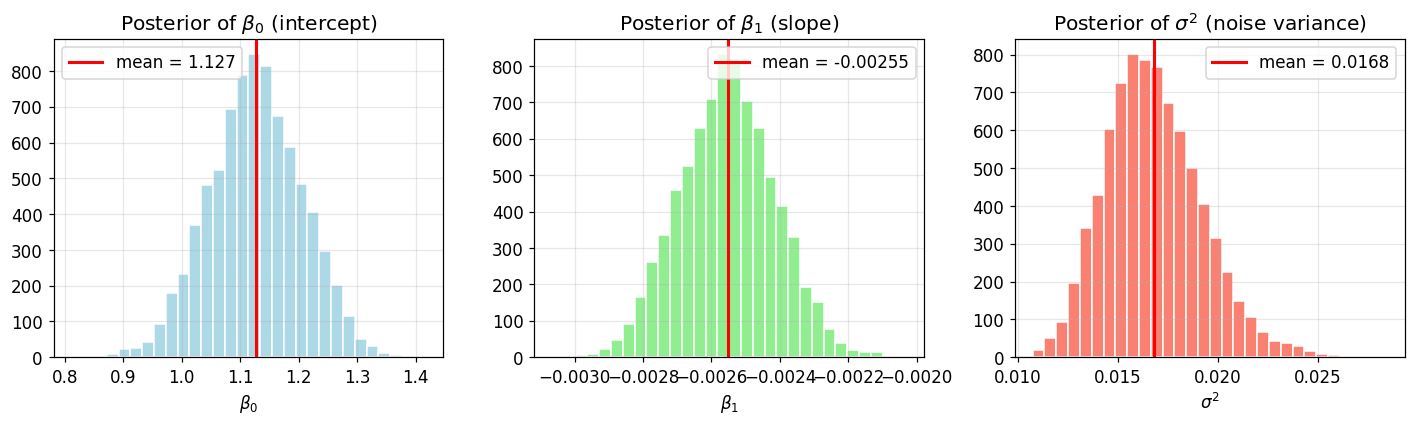

In [ ]:
# Q1: posterior histograms
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].hist(beta0_samples, bins=30, color="lightblue", edgecolor="white")
axes[0].axvline(beta0_hat, color="red", lw=2, label=f"mean = {beta0_hat:.3f}")
axes[0].set_title(r"Posterior of $\beta_0$ (intercept)")
axes[0].set_xlabel(r"$\beta_0$")
axes[0].legend()

axes[1].hist(beta1_samples, bins=30, color="lightgreen", edgecolor="white")
axes[1].axvline(beta1_hat, color="red", lw=2, label=f"mean = {beta1_hat:.5f}")
axes[1].set_title(r"Posterior of $\beta_1$ (slope)")
axes[1].set_xlabel(r"$\beta_1$")
axes[1].legend()

sigma2_samples = sigma_samples ** 2
axes[2].hist(sigma2_samples, bins=30, color="salmon", edgecolor="white")
axes[2].axvline(sigma2_samples.mean(), color="red", lw=2,
                label=f"mean = {sigma2_samples.mean():.4f}")
axes[2].set_title(r"Posterior of $\sigma^2$ (noise variance)")
axes[2].set_xlabel(r"$\sigma^2$")
axes[2].legend()

plt.tight_layout()
plt.show()

A single straight line clearly underfits — the data is flat at low range and drops sharply at higher range. This motivates the GP approach in Part 2.

## Part 2 — Gaussian Process Regression on LIDAR

Kernel: $k(x, x') = \sigma_f^2 \exp\!\left(-\frac{(x-x')^2}{2\ell^2}\right) + \sigma_n^2\,\delta_{xx'}$

In sklearn: `C(σ_f²) * RBF(length_scale=ℓ) + WhiteKernel(noise_level=σ_n²)`. All three hyperparameters are optimised by maximising the marginal log-likelihood.

Plots show two bands:
- **Probability interval for $f$** (darker): $\mu \pm 1.96\,\text{sd}_f$
- **Predictive interval for $y$** (lighter): $\mu \pm 1.96\sqrt{\text{sd}_f^2 + \sigma_n^2}$

In [ ]:
def fit_and_plot_gp(lidar_df, train_idx, test_idx, title_prefix,
                     kernel_kind="RBF"):
    """Fit a GP, plot it with both intervals, return (gp, rmse, sigma_n)."""

    X_tr = lidar_df.iloc[train_idx][["range"]].values
    y_tr = lidar_df.iloc[train_idx]["logratio"].values
    X_te = lidar_df.iloc[test_idx][["range"]].values
    y_te = lidar_df.iloc[test_idx]["logratio"].values

    # pick base kernel
    if kernel_kind == "RBF":
        base = RBF(length_scale=50.0, length_scale_bounds=(1.0, 1e4))
    elif kernel_kind == "Matern32":
        base = Matern(length_scale=50.0, nu=1.5, length_scale_bounds=(1.0, 1e4))
    else:
        raise ValueError(kernel_kind)

    kernel = (C(1.0, (1e-3, 1e3))
              * base
              + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42,
    )
    gp.fit(X_tr, y_tr)

    # extract learned noise sigma_n from WhiteKernel
    learned_kernel = gp.kernel_
    white = learned_kernel.k2 if hasattr(learned_kernel, "k2") else None
    sigma_n = np.sqrt(white.noise_level) if white is not None else 0.0

    # predict on dense grid
    x_min = lidar_df["range"].min()
    x_max = lidar_df["range"].max()
    x_grid = np.linspace(x_min, x_max, 300).reshape(-1, 1)

    mu, sd_total = gp.predict(x_grid, return_std=True)
    # split total sd into pure function sd
    sd_f = np.sqrt(np.maximum(sd_total**2 - sigma_n**2, 0.0))

    # test RMSE
    y_pred = gp.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    # plot
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.fill_between(
        x_grid.ravel(),
        mu - 1.96 * sd_total,
        mu + 1.96 * sd_total,
        color="blue", alpha=0.10, label="95% predictive interval (y)",
    )
    ax.fill_between(
        x_grid.ravel(),
        mu - 1.96 * sd_f,
        mu + 1.96 * sd_f,
        color="blue", alpha=0.30, label="95% probability interval (f)",
    )

    ax.plot(x_grid, mu, color="blue", lw=2, label="Posterior mean of f")
    ax.scatter(X_tr, y_tr, s=18, c="grey",  alpha=0.7, label=f"Train (n={len(y_tr)})")
    ax.scatter(X_te, y_te, s=22, c="red",   alpha=0.9, label=f"Test  (n={len(y_te)})")

    ax.set_xlabel("range")
    ax.set_ylabel("logratio")
    ax.set_title(f"{title_prefix}   |   Test RMSE = {rmse:.4f}")
    ax.legend(loc="lower left", fontsize=9)
    plt.show()

    print(f"  Learned kernel: {gp.kernel_}")
    print(f"  Estimated noise sigma_n = {sigma_n:.4f}")
    print(f"  Test RMSE = {rmse:.4f}")
    print(f"  Log-marginal-likelihood = {gp.log_marginal_likelihood_value_:.3f}")

    return gp, rmse, sigma_n

### Q2.1 — 80:20 split

=== Q2.1: 80:20 split ===


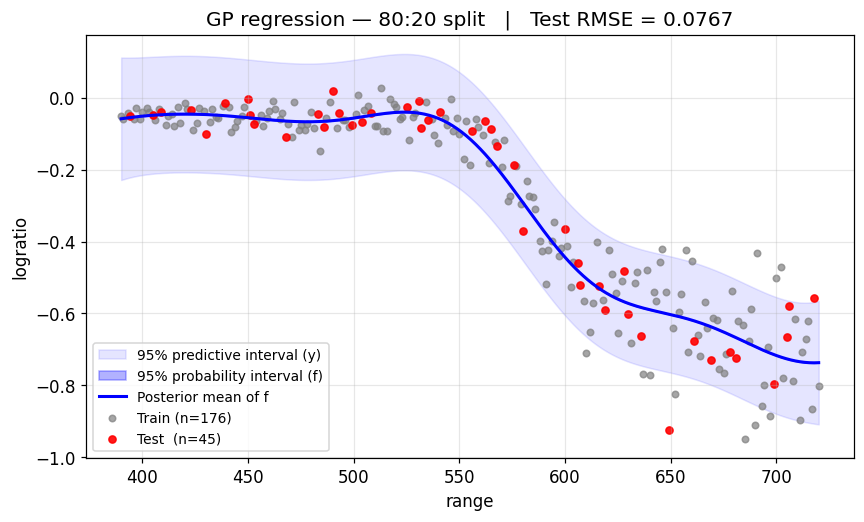

  Learned kernel: 0.873**2 * RBF(length_scale=54.8) + WhiteKernel(noise_level=0.0831)
  Estimated noise sigma_n = 0.2883
  Test RMSE = 0.0767
  Log-marginal-likelihood = -48.388


In [ ]:
# Q2.1: 80:20 train/test split
np.random.seed(RNG_SEED)
n = len(lidar)
perm = np.random.permutation(n)

n_tr_80 = int(0.8 * n)
train_idx_80 = perm[:n_tr_80]
test_idx_80  = perm[n_tr_80:]

print("=== Q2.1: 80:20 split ===")
gp_80, rmse_80, sigma_n_80 = fit_and_plot_gp(
    lidar, train_idx_80, test_idx_80,
    "GP regression — 80:20 split",
    kernel_kind="RBF",
)

### Q2.2 — 70:30 split

=== Q2.2: 70:30 split ===


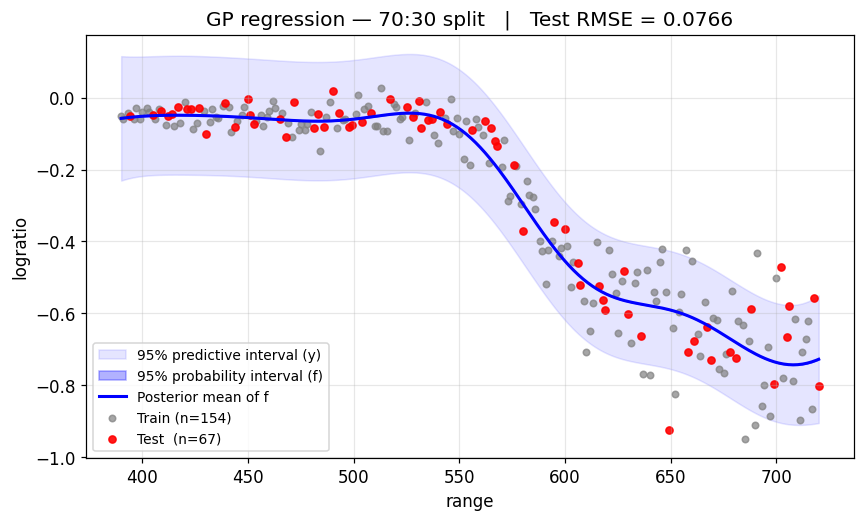

  Learned kernel: 0.853**2 * RBF(length_scale=49.6) + WhiteKernel(noise_level=0.0843)
  Estimated noise sigma_n = 0.2903
  Test RMSE = 0.0766
  Log-marginal-likelihood = -45.902


In [ ]:
# Q2.2: 70:30 train/test split
np.random.seed(RNG_SEED)
perm = np.random.permutation(n)

n_tr_70 = int(0.7 * n)
train_idx_70 = perm[:n_tr_70]
test_idx_70  = perm[n_tr_70:]

print("=== Q2.2: 70:30 split ===")
gp_70, rmse_70, sigma_n_70 = fit_and_plot_gp(
    lidar, train_idx_70, test_idx_70,
    "GP regression — 70:30 split",
    kernel_kind="RBF",
)

### Q2.3 — Compare 80:20 vs 70:30

In [ ]:
# Q2.3: side-by-side RMSE comparison
print("=== Q2.3: Comparison of 80:20 vs 70:30 ===")
print(f"  80:20  Test RMSE = {rmse_80:.4f}   (n_train = {n_tr_80})")
print(f"  70:30  Test RMSE = {rmse_70:.4f}   (n_train = {n_tr_70})")

=== Q2.3: Comparison of 80:20 vs 70:30 ===
  80:20  Test RMSE = 0.0767   (n_train = 176)
  70:30  Test RMSE = 0.0766   (n_train = 154)


**Observations:**
- RMSE is comparable across splits — the GP is fairly robust to the train size here.
- The probability band for $f$ is wider in the 70:30 case where training data is sparser.
- The predictive band for $y$ is dominated by $\sigma_n$ and similar in both cases.

### Q2.4 — Squared Exponential vs Matern 3/2

Note: Squared Exponential, RBF, and Gaussian kernel are the **same** kernel under different names. To make this question meaningful we compare RBF against Matern 3/2, whose sample paths are only once differentiable (rougher prior on $f$).

=== Q2.4: Matern 3/2 kernel on the 80:20 split ===


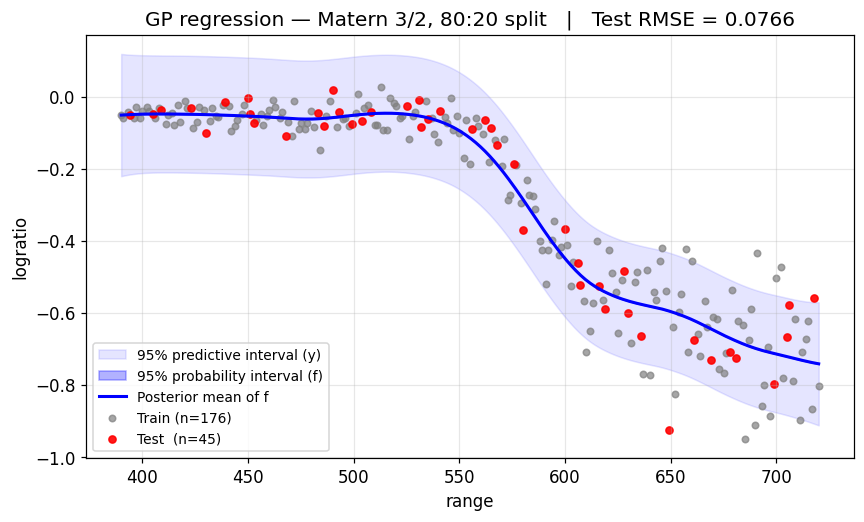

  Learned kernel: 1.17**2 * Matern(length_scale=169, nu=1.5) + WhiteKernel(noise_level=0.0824)
  Estimated noise sigma_n = 0.2870
  Test RMSE = 0.0766
  Log-marginal-likelihood = -47.241

RBF (SquaredExp)  test RMSE = 0.0767
Matern 3/2        test RMSE = 0.0766


In [ ]:
# Q2.4: refit with Matern 3/2 on the 80:20 split
print("=== Q2.4: Matern 3/2 kernel on the 80:20 split ===")
gp_mat, rmse_mat, sigma_n_mat = fit_and_plot_gp(
    lidar, train_idx_80, test_idx_80,
    "GP regression — Matern 3/2, 80:20 split",
    kernel_kind="Matern32",
)

print()
print(f"RBF (SquaredExp)  test RMSE = {rmse_80:.4f}")
print(f"Matern 3/2        test RMSE = {rmse_mat:.4f}")

### Q2.5 — Optimised kernels side-by-side

Optimised kernels:
  RBF      : 0.873**2 * RBF(length_scale=54.8) + WhiteKernel(noise_level=0.0831)
  Matern32 : 1.17**2 * Matern(length_scale=169, nu=1.5) + WhiteKernel(noise_level=0.0824)
  Log-marginal-likelihood (RBF)      = -48.388
  Log-marginal-likelihood (Matern32) = -47.241


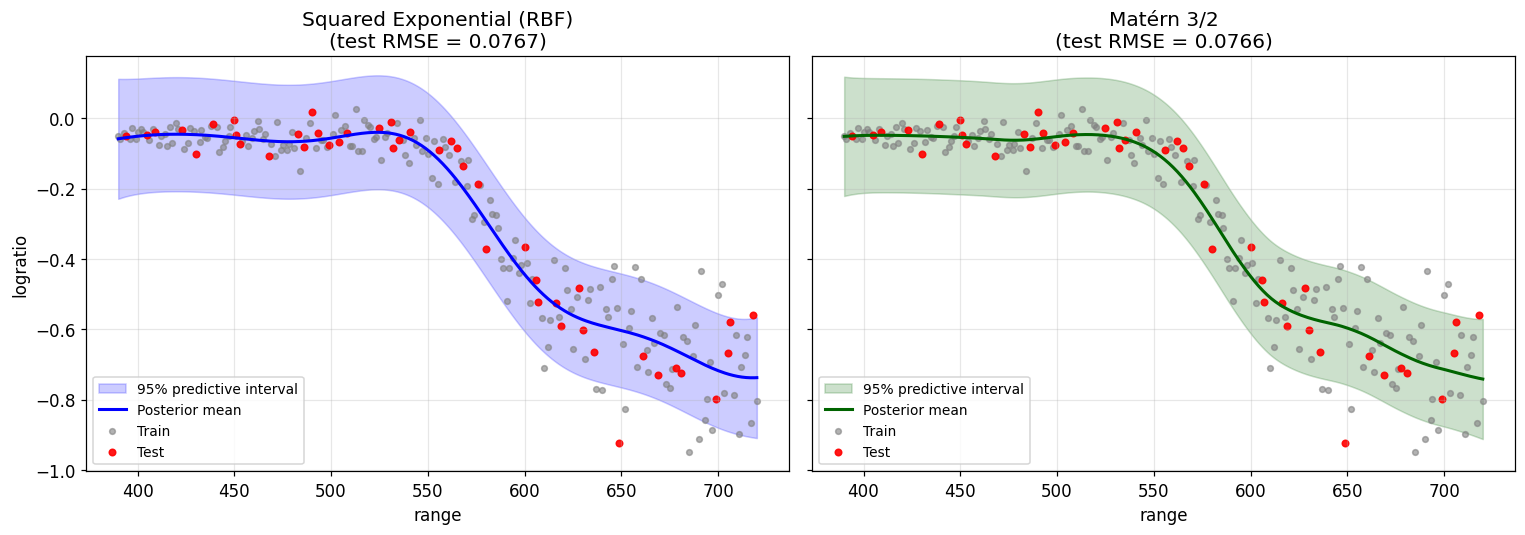

In [ ]:
# Q2.5: print optimised hyperparameters
print("Optimised kernels:")
print(f"  RBF      : {gp_80.kernel_}")
print(f"  Matern32 : {gp_mat.kernel_}")
print(f"  Log-marginal-likelihood (RBF)      = {gp_80.log_marginal_likelihood_value_:.3f}")
print(f"  Log-marginal-likelihood (Matern32) = {gp_mat.log_marginal_likelihood_value_:.3f}")

# Q2.5: side-by-side plot
x_grid = np.linspace(lidar["range"].min(), lidar["range"].max(), 300).reshape(-1, 1)
X_tr = lidar.iloc[train_idx_80][["range"]].values
y_tr = lidar.iloc[train_idx_80]["logratio"].values
X_te = lidar.iloc[test_idx_80][["range"]].values
y_te = lidar.iloc[test_idx_80]["logratio"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, gp_model, name, rmse, color in [
    (axes[0], gp_80,  "Squared Exponential (RBF)", rmse_80,  "blue"),
    (axes[1], gp_mat, "Matérn 3/2",               rmse_mat, "darkgreen"),
]:
    mu, sd = gp_model.predict(x_grid, return_std=True)
    ax.fill_between(x_grid.ravel(), mu - 1.96*sd, mu + 1.96*sd,
                    color=color, alpha=0.20, label="95% predictive interval")
    ax.plot(x_grid, mu, color=color, lw=2, label="Posterior mean")
    ax.scatter(X_tr, y_tr, s=14, c="grey", alpha=0.6, label="Train")
    ax.scatter(X_te, y_te, s=18, c="red",  alpha=0.9, label="Test")
    ax.set_title(f"{name}\n(test RMSE = {rmse:.4f})")
    ax.set_xlabel("range")
    ax.legend(loc="lower left", fontsize=9)

axes[0].set_ylabel("logratio")
plt.tight_layout()
plt.show()

**Comments on Q2.5:**
- After hyperparameter optimisation both kernels give very similar test RMSEs.
- The Matern 3/2 fit captures the steep transition near `range ≈ 600` slightly better.
- The marginal log-likelihood gives a principled way to pick between them.

## Part 3 — GP regression on synthetic functions

### Q3.1 — $f_1(x) = \dfrac{\sin(x)}{x} + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.03^2)$, $-20 < x < 20$

Optimised kernel: 0.376**2 * RBF(length_scale=2.7) + WhiteKernel(noise_level=0.000848)


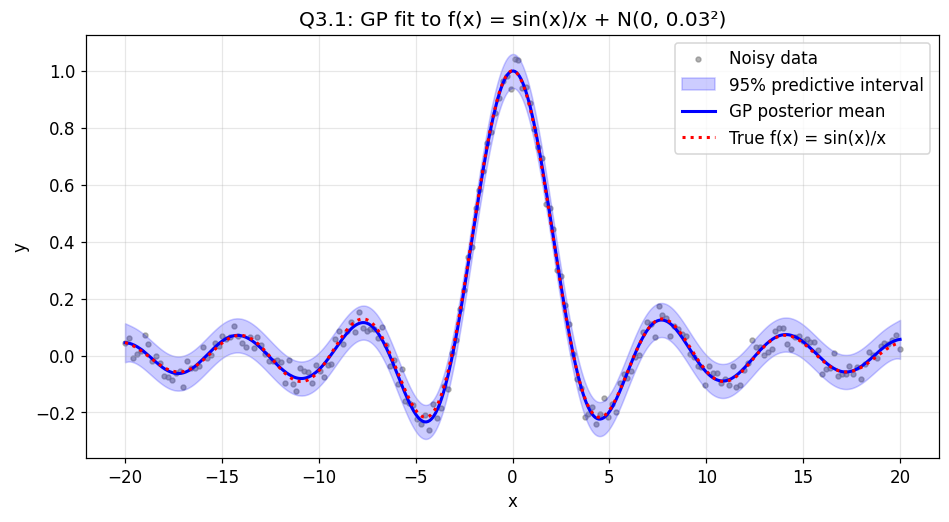

In [ ]:
# Q3.1: sinc function with Gaussian noise
np.random.seed(RNG_SEED)

x1 = np.linspace(-20, 20, 200)
# sinc with limit 1 at x = 0
f1_true = np.where(np.abs(x1) < 1e-9, 1.0, np.sin(x1) / x1)
y1 = f1_true + np.random.normal(0, 0.03, len(x1))

X1 = x1.reshape(-1, 1)

kernel1 = C(1.0) * RBF(length_scale=2.0) + WhiteKernel(noise_level=0.001)
gp1 = GaussianProcessRegressor(kernel=kernel1, n_restarts_optimizer=10,
                                random_state=42)
gp1.fit(X1, y1)
print("Optimised kernel:", gp1.kernel_)

# predict on dense grid + true curve for comparison
xg1 = np.linspace(-20, 20, 500).reshape(-1, 1)
mu1, sd1 = gp1.predict(xg1, return_std=True)
truth1 = np.where(np.abs(xg1.ravel()) < 1e-9, 1.0, np.sin(xg1.ravel()) / xg1.ravel())

plt.figure(figsize=(10, 5))
plt.scatter(x1, y1, s=10, c="grey", alpha=0.6, label="Noisy data")
plt.fill_between(xg1.ravel(), mu1 - 1.96*sd1, mu1 + 1.96*sd1,
                 color="blue", alpha=0.20, label="95% predictive interval")
plt.plot(xg1, mu1,    color="blue", lw=2, label="GP posterior mean")
plt.plot(xg1, truth1, color="red",  lw=2, ls=":", label="True f(x) = sin(x)/x")
plt.title("Q3.1: GP fit to f(x) = sin(x)/x + N(0, 0.03²)")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(loc="upper right")
plt.show()

### Q3.2 — Eight hand-picked points

```
x = (-4, -3, -2, -1,  0, 0.5,  1,  2)
y = (-2,  0, -0.5, 1, 2,   1,  0, -1)
```

Optimised kernel: 1.42**2 * RBF(length_scale=0.906) + WhiteKernel(noise_level=1.74e-09)


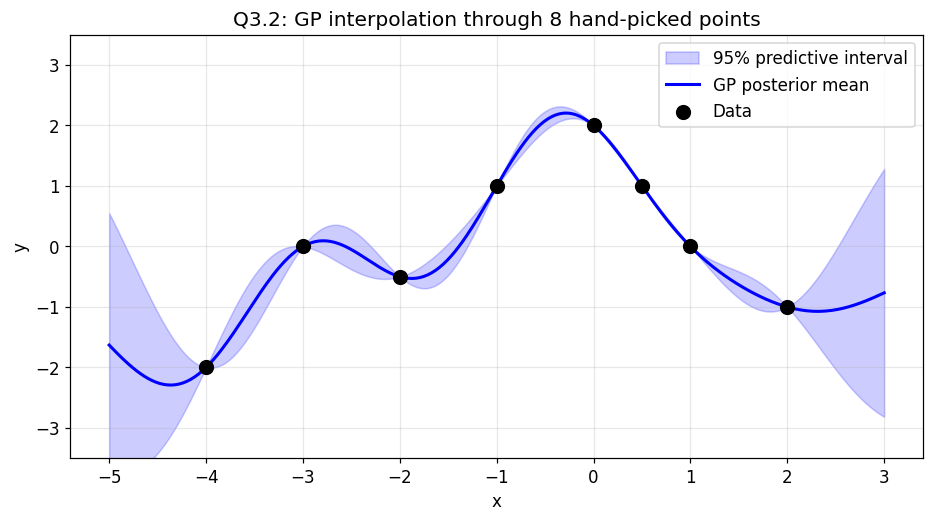

In [ ]:
# Q3.2: GP through 8 specified points
x2 = np.array([-4, -3, -2, -1,  0, 0.5,  1,  2], dtype=float)
y2 = np.array([-2,  0, -0.5, 1, 2,   1,  0, -1], dtype=float)
X2 = x2.reshape(-1, 1)

# tiny noise floor so the GP near-interpolates
kernel2 = C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-5,
                                                        noise_level_bounds=(1e-10, 1e-2))
gp2 = GaussianProcessRegressor(kernel=kernel2, n_restarts_optimizer=10,
                                random_state=42)
gp2.fit(X2, y2)
print("Optimised kernel:", gp2.kernel_)

xg2 = np.linspace(-5, 3, 400).reshape(-1, 1)
mu2, sd2 = gp2.predict(xg2, return_std=True)

plt.figure(figsize=(10, 5))
plt.fill_between(xg2.ravel(), mu2 - 1.96*sd2, mu2 + 1.96*sd2,
                 color="blue", alpha=0.20, label="95% predictive interval")
plt.plot(xg2, mu2, color="blue", lw=2, label="GP posterior mean")
plt.scatter(x2, y2, s=80, c="black", zorder=5, label="Data")
plt.title("Q3.2: GP interpolation through 8 hand-picked points")
plt.xlabel("x"); plt.ylabel("y")
plt.ylim(-3.5, 3.5)
plt.legend(loc="upper right")
plt.show()

### Q3.3 — Composite test function

$x_1 = 2x + 0.5$, $\quad y = \dfrac{\sin(10\pi x_1)}{2 x_1} + (x_1 - 1)^4$, evaluated at the 10 given $x$ points.

Optimised kernel: 1.46**2 * RBF(length_scale=0.176) + WhiteKernel(noise_level=1e-05)


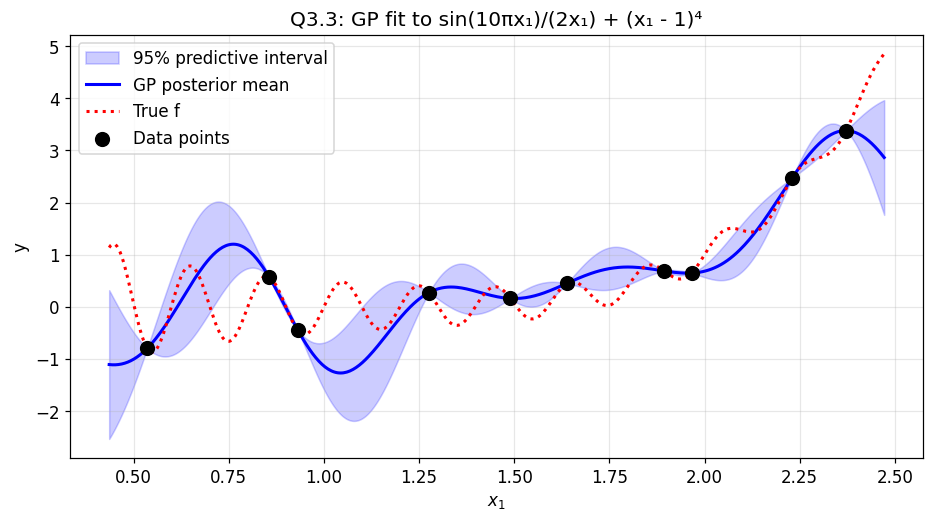

In [ ]:
# Q3.3: composite function at 10 points
x_orig = np.array([0.178, 0.388, 0.865, 0.697, 0.569,
                    0.216, 0.733, 0.0179, 0.936, 0.495])
x1_q3 = 2 * x_orig + 0.5
y3    = np.sin(10 * np.pi * x1_q3) / (2 * x1_q3) + (x1_q3 - 1) ** 4

X3 = x1_q3.reshape(-1, 1)

kernel3 = C(1.0) * RBF(length_scale=0.1) + WhiteKernel(noise_level=1e-5,
                                                        noise_level_bounds=(1e-10, 1e-2))
gp3 = GaussianProcessRegressor(kernel=kernel3, n_restarts_optimizer=15,
                                random_state=42)
gp3.fit(X3, y3)
print("Optimised kernel:", gp3.kernel_)

xg3 = np.linspace(x1_q3.min() - 0.1, x1_q3.max() + 0.1, 500).reshape(-1, 1)
mu3, sd3 = gp3.predict(xg3, return_std=True)
truth3 = np.sin(10 * np.pi * xg3.ravel()) / (2 * xg3.ravel()) + (xg3.ravel() - 1) ** 4

plt.figure(figsize=(10, 5))
plt.fill_between(xg3.ravel(), mu3 - 1.96*sd3, mu3 + 1.96*sd3,
                 color="blue", alpha=0.20, label="95% predictive interval")
plt.plot(xg3, mu3,    color="blue", lw=2, label="GP posterior mean")
plt.plot(xg3, truth3, color="red",  lw=2, ls=":", label="True f")
plt.scatter(x1_q3, y3, s=80, c="black", zorder=5, label="Data points")
plt.title("Q3.3: GP fit to sin(10πx₁)/(2x₁) + (x₁ - 1)⁴")
plt.xlabel(r"$x_1$"); plt.ylabel("y")
plt.legend(loc="upper left")
plt.show()